# **Week 14 | Image Classification using Transfer Learning**

 - Trash types detection using Pre-trained model - MobilenetV2
 - Detect trash types with Transfer Learning, TensorFlow and Keras
 - Membandingkan 2 model untuk mengetahui apakah terdapat Overfitting
 - Overfitting Handling menggunakan beberapa teknik seperti **Data Augmentation, EarlyStopping**

**Importing the pre-requisites**

Install TensorFlow and Keras framework 

In [1]:
%pip install tensorflow 

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



Pada tahap ini dilakukan import library yang dibutuhkan dalam proses klasifikasi citra menggunakan Transfer Learning. Library yang digunakan meliputi TensorFlow dan Keras untuk membangun model deep learning, NumPy untuk pengolahan data numerik, Matplotlib untuk visualisasi hasil, serta Scikit-learn untuk evaluasi model.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report

**Dataset Path**


Dataset yang digunakan merupakan Trash Type Image Dataset yang berisi enam kategori jenis sampah. Pada tahap ini ditentukan lokasi folder dataset yang akan digunakan selama proses pelatihan.

- Dataset : https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

In [10]:
import os

dataset_path = "DATASETS/archive (1)/TrashType_Image_Dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)

DATASETS/archive (1)/TrashType_Image_Dataset
DATASETS/archive (1)/TrashType_Image_Dataset\cardboard
DATASETS/archive (1)/TrashType_Image_Dataset\glass
DATASETS/archive (1)/TrashType_Image_Dataset\metal
DATASETS/archive (1)/TrashType_Image_Dataset\paper
DATASETS/archive (1)/TrashType_Image_Dataset\plastic
DATASETS/archive (1)/TrashType_Image_Dataset\trash


**Cek GPU untuk TensorFlow**

Pada TensorFlow 2.11, GPU native sudah tidak mendukung, Proses training akan dilakukan menggunakan CPU Runtime

Tahap ini bertujuan untuk memastikan TensorFlow telah terinstal dengan benar serta mengetahui apakah proses training dapat memanfaatkan GPU atau hanya menggunakan CPU.

In [11]:
print("TensorFlow version:", tf.__version__)
print("GPU:", "Available" if tf.config.list_physical_devices('GPU') else "Not Available")

TensorFlow version: 2.21.0
GPU: Not Available


**Load Dataset menggunakan TensorFlow**

Pada dataset yang digunakan, tidak terdapat folder **train, test, validation (val)**

Dataset dimuat menggunakan fungsi `image_dataset_from_directory()`. Data kemudian dibagi menjadi data training dan validation dengan rasio 80:20 menggunakan parameter `validation_split`.

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


**Menampilkan Nama Kelas**


Tahap ini bertujuan untuk mengetahui seluruh kelas yang terdapat pada dataset sehingga dapat digunakan pada proses pelatihan maupun evaluasi model.

In [14]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


**Dataset Visualization - Visualisasi Dataset**

Beberapa sampel gambar dari dataset ditampilkan untuk memastikan bahwa dataset berhasil dimuat dengan benar serta melihat variasi gambar pada masing-masing kelas.

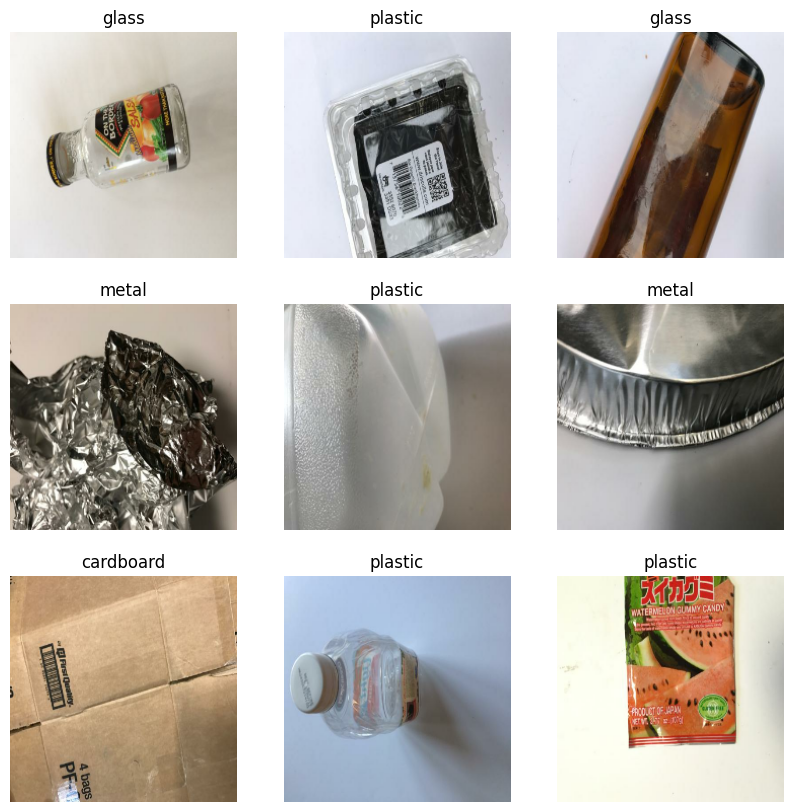

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

**Optimasi Dataset menggunakan Prefetch**

Dataset dioptimalkan menggunakan metode **Prefetch** agar proses pembacaan data selama pelatihan menjadi lebih efisien dan mempercepat proses training model.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

**Load Pre-trained model - MobileNet V2**

Pada projek ini digunakan **MobileNetV2** yang telah dilatih sebelumnya menggunakan dataset ImageNet. Model ini dimanfaatkan sebagai feature extractor sehingga proses pelatihan menjadi lebih cepat dan akurat.

In [17]:
mobile_net = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), 
    include_top=False, 
    weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Freeze Layer**

Seluruh layer pada MobileNetV2 dibekukan (freeze) sehingga bobot hasil pelatihan pada ImageNet tidak berubah selama proses training. Hanya layer klasifikasi yang akan dilatih menggunakan dataset sampah.

In [18]:
mobile_net.trainable = False

**Model 1 - Baseline**

Model klasifikasi dibangun menggunakan MobileNetV2 sebagai feature extractor, kemudian ditambahkan GlobalAveragePooling2D dan Dense Layer sebagai classifier untuk mengenali enam jenis sampah.

In [20]:
model = keras.Sequential([

    layers.Rescaling(1./255),

    mobile_net,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dense(len(class_names), activation="softmax")

])

**Compiling**

Model dikompilasi menggunakan optimizer Adam, fungsi loss Sparse Categorical Crossentropy, serta metrik Accuracy untuk mengukur performa model selama pelatihan.

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Model Summary**

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

**Proses Training**

Model dilatih menggunakan data training selama 20 epoch dengan memanfaatkan data validation untuk memonitor performa model pada setiap epoch.

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


c:\DATA\RE600\MACHINE LEARNING + DEEP LEARNING\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 333ms/step - accuracy: 0.6820 - loss: 0.8574 - val_accuracy: 0.7762 - val_loss: 0.6346
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.8457 - loss: 0.4368 - val_accuracy: 0.8059 - val_loss: 0.5443
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.9001 - loss: 0.2882 - val_accuracy: 0.7921 - val_loss: 0.5790
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - accuracy: 0.9471 - loss: 0.1966 - val_accuracy: 0.8455 - val_loss: 0.4790
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - accuracy: 0.9644 - loss: 0.1300 - val_accuracy: 0.8337 - val_loss: 0.5008
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 310ms/step - accuracy: 0.9862 - loss: 0.0859 - val_accuracy: 0.8376 - val_loss: 0.5375
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step - accuracy: 0.9941 - loss: 0.0576 - val_accuracy: 0.8396 - val_loss: 0.5099
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step - accuracy: 0.9955 - loss: 0.0430 - val_accuracy: 0.839

**Plot Accuracy**

Grafik accuracy ditampilkan untuk melihat perkembangan akurasi model pada data training dan validation selama proses pelatihan.

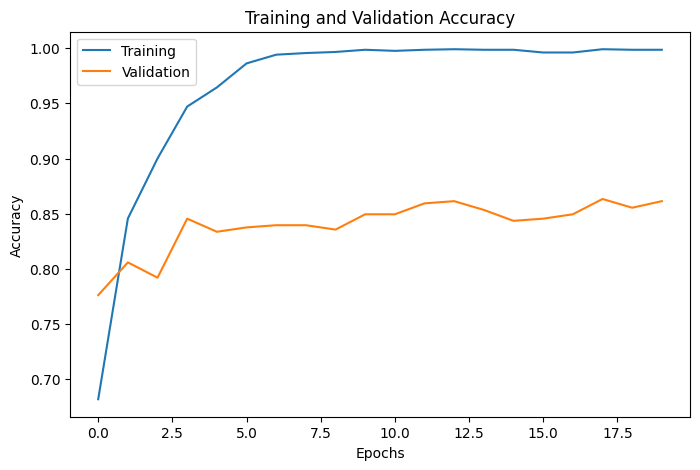

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

**Plot Loss**

Grafik loss digunakan untuk mengetahui apakah model mengalami overfitting atau underfitting selama proses pelatihan.

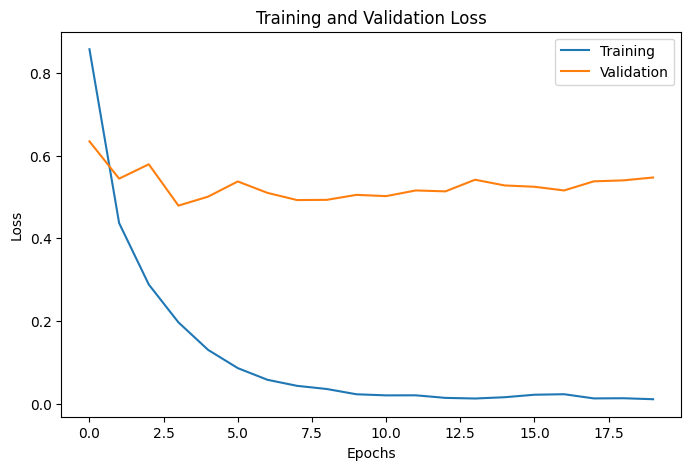

In [34]:
plt.figure(figsize = (8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

**Analisis Overfitting**
- **Accuracy**

Berdasarkan grafik, training accuracy meningkat secara signifikan hingga hampir mencapai 100%, sedangkan validation accuracy hanya meningkat hingga sekitar 86% kemudian cenderung stagnan. Perbedaan yang cukup besar antara kedua kurva menunjukkan bahwa model sangat baik dalam mempelajari data training, namun kurang mampu mempertahankan performanya pada data validasi. Kondisi ini merupakan indikasi bahwa model mengalami **overfitting**, yaitu model mulai menghafal data training sehingga kemampuan generalisasinya terhadap data baru menjadi menurun.

- **Loss**

Grafik menunjukkan bahwa training loss terus menurun hingga mendekati nol, yang menandakan kesalahan prediksi pada data training semakin kecil. Sebaliknya, validation loss hanya menurun pada beberapa epoch awal, kemudian cenderung stagnan dan sedikit berfluktuasi tanpa mengalami perbaikan yang signifikan. Perbedaan pola antara training loss dan validation loss memperkuat indikasi bahwa model mengalami **overfitting**, karena peningkatan performa pada data training tidak diikuti oleh peningkatan performa pada data validasi.

Berdasarkan grafik accuracy dan loss, Model 1 mengalami **overfitting**. Hal ini ditunjukkan oleh gap yang cukup besar antara training dan validation accuracy, serta training loss yang terus menurun sementara validation loss cenderung stagnan. Oleh karena itu, diperlukan teknik penanganan overfitting seperti **Data Augmentation**, dan **EarlyStopping** agar model memiliki kemampuan generalisasi yang lebih baik.

**Overfitting Handling**
- Data Augmentation
- EarlyStopping

Data Augmentation digunakan untuk meningkatkan variasi data training melalui transformasi acak seperti flipping, rotasi, dan zoom sehingga model mampu melakukan generalisasi dengan lebih baik.

In [28]:
# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

**Model 2 - Model baru yang digunakan untuk Overfitting Handling**

In [29]:
base_model2 = tf.keras.applications.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights = 'imagenet'
)

base_model2.trainable = False

**Build Model**

Model kedua dibangun dengan arsitektur yang sama seperti model pertama, namun ditambahkan Data Augmentation sebagai teknik penanganan overfitting.

In [30]:
model2 = keras.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    base_model2,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),

    layers.Dense(len(class_names), activation="softmax")

])


**Compiling**

Model kedua dikompilasi menggunakan konfigurasi yang sama agar hasilnya dapat dibandingkan secara adil dengan model pertama.

In [31]:
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**EarlyStopping**

Callback EarlyStopping digunakan untuk menghentikan proses training secara otomatis apabila performa validation tidak lagi mengalami peningkatan sehingga dapat mencegah overfitting.

In [32]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


**Training dengan Model 2**

Model kedua dilatih kembali menggunakan dataset yang sama setelah diterapkan teknik penanganan overfitting.

In [33]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


c:\DATA\RE600\MACHINE LEARNING + DEEP LEARNING\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 348ms/step - accuracy: 0.5495 - loss: 1.1851 - val_accuracy: 0.7584 - val_loss: 0.7140
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.6983 - loss: 0.8074 - val_accuracy: 0.7426 - val_loss: 0.6311
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.7413 - loss: 0.7204 - val_accuracy: 0.8178 - val_loss: 0.5786
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 343ms/step - accuracy: 0.7656 - loss: 0.6431 - val_accuracy: 0.7663 - val_loss: 0.5780
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.7636 - loss: 0.6249 - val_accuracy: 0.8119 - val_loss: 0.5243
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 343ms/step - accuracy: 0.7849 - loss: 0.5931 - val_accuracy: 0.8099 - val_loss: 0.5490
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - accuracy: 0.7799 - loss: 0.5964 - val_accuracy: 0.8198 - val_loss: 0.5239
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 353ms/step - accuracy: 0.7839 - loss: 0.5658 - val_accuracy: 0.827

In [37]:
print("Jumlah epoch:", len(history2.history['loss']))
print(history2.history.keys())

print(history2.params)

Jumlah epoch: 19
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{'verbose': 'auto', 'epochs': 20, 'steps': 64}


In [39]:
print(history2.epoch)
print(history2.history['loss'])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
[1.185063362121582, 0.8073704838752747, 0.7204317450523376, 0.643101155757904, 0.6248849034309387, 0.5930647850036621, 0.5963668823242188, 0.5657711625099182, 0.5405972003936768, 0.506863534450531, 0.517277717590332, 0.5047013163566589, 0.4705027639865875, 0.45872238278388977, 0.4274248778820038, 0.4692921042442322, 0.42140644788742065, 0.42844632267951965, 0.41094958782196045]


**Plot Accuracy - Model 2**

Grafik accuracy model kedua digunakan untuk melihat pengaruh teknik penanganan overfitting terhadap performa model.

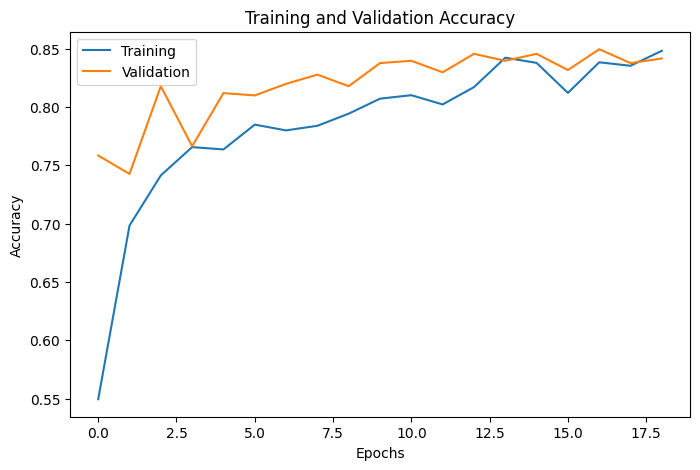

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

**Plot Loss - Model 2**

Grafik loss model kedua digunakan untuk membandingkan performa model sebelum dan sesudah dilakukan penanganan overfitting.

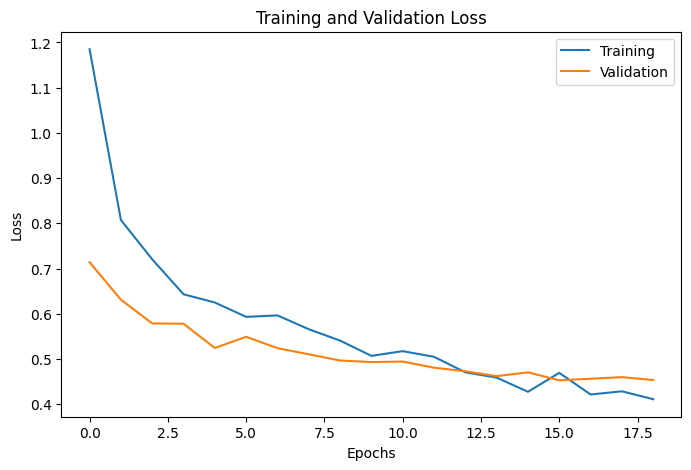

In [41]:
plt.figure(figsize = (8, 5))

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

**Evaluasi Model**

Tahap evaluasi dilakukan menggunakan data validation untuk mengetahui performa akhir model setelah proses pelatihan selesai.
Model melakukan prediksi terhadap seluruh data validation. Hasil prediksi ini akan digunakan untuk menghitung berbagai metrik evaluasi seperti **Classification Report** dan **Confusion Matrix.**

In [42]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model2.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [44]:
print(len(y_true))
print(len(y_pred))

505
505


**Classification Report**


**Classification Report** digunakan untuk mengevaluasi performa model pada setiap kelas berdasarkan nilai Precision, Recall, F1-score, dan Accuracy.

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.78      0.87      0.82        69
       glass       0.90      0.77      0.83       102
       metal       0.82      0.95      0.88        88
       paper       0.85      0.85      0.85       123
     plastic       0.83      0.79      0.81        89
       trash       0.74      0.68      0.71        34

    accuracy                           0.83       505
   macro avg       0.82      0.82      0.82       505
weighted avg       0.83      0.83      0.83       505



**Confusion Matrix**

**Confusion Matrix** digunakan untuk melihat jumlah prediksi yang benar maupun salah pada setiap kelas sehingga dapat diketahui kelas mana yang masih sering mengalami kesalahan klasifikasi.

Confusion Matrix: [[ 60   0   0   9   0   0]
 [  1  79  12   2   8   0]
 [  0   2  84   0   1   1]
 [ 13   0   1 104   2   3]
 [  2   6   4   3  70   4]
 [  1   1   2   4   3  23]]


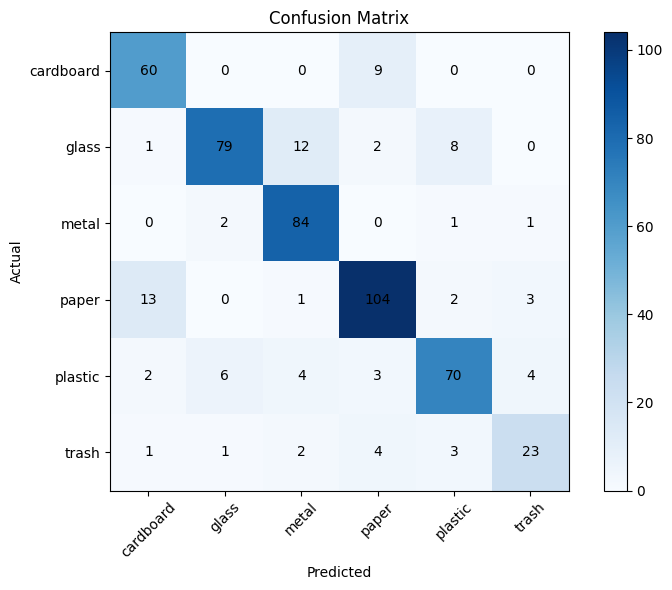

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:", cm)


# Visualisasi Confusion Matrix
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.tight_layout()
plt.show()

Berdasarkan confusion matrix, sebagian besar prediksi berada pada diagonal utama, yang menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data dengan benar. Kelas **paper** dan **metal** memiliki jumlah prediksi benar tertinggi, sedangkan masih terdapat beberapa kesalahan klasifikasi pada kelas yang memiliki karakteristik visual serupa, seperti **paper** dengan **cardboard** serta **glass** dengan **metal**. Secara keseluruhan, hasil ini menunjukkan bahwa model memiliki performa klasifikasi yang baik, meskipun masih terdapat beberapa kesalahan pada kelas-kelas tertentu.